In [1]:
import pandas as pd 
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from shapely.geometry import Point
from shapely import wkt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import  LogisticRegression

In [2]:
### Load in the original master file. 
df_original = pd.read_csv("master_file.csv")

Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.


In [3]:
df_original

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,A324B30D9C1F6CFE,electric_bike,2026-03-11 18:50:05.658,2026-03-11 19:02:07.383,Monroe St & Bedford Ave,4368.05,Jefferson Ave & Patchen Ave,4375.02,40.685144,-73.953809,40.686090,-73.926280,member
1,4D0D692F5FE64064,electric_bike,2026-03-08 17:39:18.215,2026-03-08 17:54:17.959,East End Ave & E 86 St,7113.08,E 77 St & 1 Ave,7020.02,40.775186,-73.944461,40.770956,-73.953562,member
2,2BEE12E018E094A5,electric_bike,2026-03-06 12:37:33.174,2026-03-06 13:03:23.951,Washington Pl & Broadway,5755.01,7 St & 3 Ave,3996.01,40.729039,-73.994046,40.672603,-73.989830,member
3,7800A32885CD2D67,electric_bike,2026-03-09 22:48:26.091,2026-03-09 23:02:24.085,Kent Ave & Grand St,5388.01,Henry St & Middagh St,4861.05,40.716425,-73.965940,40.700300,-73.991581,member
4,56D7FEABCE16E004,electric_bike,2026-03-07 13:37:15.215,2026-03-07 13:57:59.731,Monroe St & Bedford Ave,4368.05,7 St & 3 Ave,3996.01,40.685144,-73.953809,40.672603,-73.989830,member
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2945748,DD55FE6FB5F91866,electric_bike,2026-03-28 15:40:17.068,2026-03-28 15:54:28.292,Liberty St & Broadway,5105.01,Washington St & Gansevoort St,6039.06,40.709056,-74.010434,40.739323,-74.008119,casual
2945749,808EA2FD4AA5E432,electric_bike,2026-03-21 11:43:55.839,2026-03-21 11:50:33.051,Colonial Rd & 68 St,2843.01,56 St & 2 Ave,3138.03,40.638410,-74.030930,40.645705,-74.020292,casual
2945750,3ED3071BDE18EBF7,electric_bike,2026-03-24 17:51:20.372,2026-03-24 17:58:25.206,W 48 St & Rockefeller Plaza,6626.11,5 Ave & E 30 St,6248.08,40.757769,-73.979294,40.745985,-73.986295,casual
2945751,10726414E3969897,classic_bike,2026-03-30 18:51:33.015,2026-03-30 18:56:54.985,Menahan St & Wyckoff Ave,4890.11,Wyckoff Ave & Jefferson St,5051.01,40.701130,-73.914220,40.707165,-73.923711,casual


### Calculating duration based off start and end time. 
#### Duartion is then binned into categories: "Very short - 0 to 10 mintues", "Short -  15 minutes", "Medium  - up to 30 minutes", 
#### "long up to 60 minutes", "Very long - up to two hours", "misdocked - over 2 hours" 

### Note to self Check number and ensure that this is correct 

In [4]:
### Calculating duration based off start and end time 
### Converting to Date Time
df_original["started_at"] = pd.to_datetime(df_original["started_at"])
df_original["ended_at"] = pd.to_datetime(df_original["ended_at"])

### Calculate math-friendly Timedelta
df_original["elapsed_delta"] = df_original["ended_at"] - df_original["started_at"]

### Create numeric minutes for binning
df_original['ride_time_m'] = (df_original['elapsed_delta'].dt.total_seconds() / 60).round(2)

### Create the HH:MM display column
h = df_original['elapsed_delta'].dt.components.hours
m = df_original['elapsed_delta'].dt.components.minutes
df_original['elapsed_time'] = h.astype(str).str.zfill(2) + ":" + m.astype(str).str.zfill(2)


### Bin duration

In [5]:
### Bin the data into categories
bins = [0, 10, 15, 30, 60, 120, np.inf]
labels = ['very short', 'short', 'medium', 'long', 'very long', 'misdocked?']
df_original['duration_category'] = pd.cut(df_original['ride_time_m'], bins=bins, labels=labels)

### Mapping which borough each start and end station is located in based on latitude and longtitude.

In [6]:
### Load in borough boundaries data set 
df_boro_csv = pd.read_csv("Borough_Boundaries_20260421.csv")

### Convert text to map shapes. 
df_boro_csv['geometry'] = df_boro_csv['the_geom'].apply(wkt.loads)
boroughs = gpd.GeoDataFrame(df_boro_csv, geometry='geometry', crs="EPSG:4326")



In [7]:
### Create unique station list, drop duplicates. 
unique_stations = df_original[['start_station_name', 'start_lat', 'start_lng']].drop_duplicates('start_station_name').copy()

### Convert stations to GeoDataFrame
geometry = [Point(xy) for xy in zip(unique_stations['start_lng'], unique_stations['start_lat'])]
geo_stations = gpd.GeoDataFrame(unique_stations, geometry=geometry, crs="EPSG:4326")

### Spatial Join by using borough name 
joined = gpd.sjoin(geo_stations, boroughs[['BoroName', 'geometry']], predicate='within', how='left')

### Map back to the master dataframe, df_master
borough_map = dict(zip(joined['start_station_name'], joined['BoroName']))
df_original['start_borough'] = df_original['start_station_name'].map(borough_map)
df_original['end_borough'] = df_original['end_station_name'].map(borough_map)

### Fill in Jersey City values & NaN values 
df_original['start_borough'] = df_original['start_borough'].fillna('Outside NYC')
df_original['end_borough'] = df_original['end_borough'].fillna('Outside NYC')



In [8]:
### Clean and export
### Drop the helper column, no longer needed for final report
df_final = df_original.drop(columns=['elapsed_delta', 'ride_time_m'])


In [9]:
### Save product to new master CSV file
df_final.to_csv("master_bike_data_2026.csv", index=False)

In [10]:
### Print process complete report
print("--- PROCESS COMPLETE ---")
print(f"Total Rows Processed: {len(df_final)}")
print("\nBorough Breakdown:")
print(df_final['start_borough'].value_counts())

--- PROCESS COMPLETE ---
Total Rows Processed: 2945753

Borough Breakdown:
Manhattan      1812235
Brooklyn        846141
Queens          202657
Bronx            83080
Outside NYC       1640
Name: start_borough, dtype: int64


### Binning data based on time of day 

In [11]:
### Define Times that the bins are based off of
### 0-5: early morning, 6-11: morning, 12-15: afternoon, 16-17: evening, 18-23: night
time_bins = [0, 6, 12, 16, 18, 24]
time_labels = ['early morning', 'morning', 'afternoon', 'evening', 'night']

In [12]:
### Extract the hour and bin it for Started At
df_original['start_time_of_day'] = pd.cut(
    df_original['started_at'].dt.hour, 
    bins=time_bins, 
    labels=time_labels, 
    right=False
)

### Extract the hour and bin it for Ended At
df_original['end_time_of_day'] = pd.cut(
    df_original['ended_at'].dt.hour, 
    bins=time_bins, 
    labels=time_labels, 
    right=False
)

### Add the Trip Type logic from before
df_original['trip_type'] = np.where(
    df_original['start_borough'] == df_original['end_borough'], 
    'Interborough', 
    'Out of borough'
)

In [13]:
print(df_original[['started_at', 'start_time_of_day', 'trip_type']].head())

               started_at start_time_of_day       trip_type
0 2026-03-11 18:50:05.658             night    Interborough
1 2026-03-08 17:39:18.215           evening    Interborough
2 2026-03-06 12:37:33.174         afternoon  Out of borough
3 2026-03-09 22:48:26.091             night    Interborough
4 2026-03-07 13:37:15.215         afternoon    Interborough


### Bin weekend as 1 and weekday as 0 

In [14]:
### 1 is weekend, 0 is weekday
df_original['is_weekend'] = df_original['started_at'].dt.dayofweek.isin([5, 6]).astype(int)

### Cleaning and organzing the dataframe

In [15]:
df_drop = df_original.copy()
columns_drop = ["ride_id", "start_lat", "start_lng", "end_lat", "end_lng", "elapsed_time", "elapsed_delta", "started_at", 
                "ended_at", "start_station_name", "start_station_id", "end_station_name", "end_station_id"]

In [16]:
df_drop = df_drop.drop(columns = columns_drop)

In [17]:
df_drop

,rideable_type,member_casual,ride_time_m,duration_category,start_borough,end_borough,start_time_of_day,end_time_of_day,trip_type,is_weekend
0,electric_bike,member,12.03,short,Brooklyn,Brooklyn,night,night,Interborough,0
1,electric_bike,member,15.00,short,Manhattan,Manhattan,evening,evening,Interborough,1
2,electric_bike,member,25.85,medium,Manhattan,Brooklyn,afternoon,afternoon,Out of borough,0
3,electric_bike,member,13.97,short,Brooklyn,Brooklyn,night,night,Interborough,0
4,electric_bike,member,20.74,medium,Brooklyn,Brooklyn,afternoon,afternoon,Interborough,1
...,...,...,...,...,...,...,...,...,...,...
2945748,electric_bike,casual,14.19,short,Manhattan,Manhattan,afternoon,afternoon,Interborough,1
2945749,electric_bike,casual,6.62,very short,Brooklyn,Brooklyn,morning,morning,Interborough,1
2945750,electric_bike,casual,7.08,very short,Manhattan,Manhattan,evening,evening,Interborough,0
2945751,classic_bike,casual,5.37,very short,Brooklyn,Brooklyn,night,night,Interborough,0


### Analysis - Classification
#### Purpose: Can we classify whether a rider is a memeber or non-memeber based of the following features: 
##### Ride Time, duration, start time of day, end time of day, trip type (interborough or out of borough) 
##### Target: Memember or Casual Rider 
##### Features: Ride Time (binned), start time of day OR  end time of day, trip type (interborough or out of borough) 

### Define Target - Member or Casual Rider 

### Define Features - Start time of day, end time of day, trip time, Ride Time, Bike Type, Weekend Rider or Weekday Rider

### One-Hot Encode & Mapping 

In [18]:
df = df_drop.copy()

In [19]:
### Mapping for Duration
duration_map = {'very short': 0, 'short': 1, 'medium': 2, 'long': 3, 'very long': 4, 'misdocked?': 5}
df['duration_encoded'] = df['duration_category'].map(duration_map)

### Mapping for Time of Day
time_map = {'early morning': 0, 'morning': 1, 'afternoon': 2, 'evening': 3, 'night': 4}
df['time_encoded'] = df['start_time_of_day'].map(time_map)

In [20]:
df = pd.get_dummies(df, columns=['start_borough', 'trip_type',"rideable_type"], drop_first=True)

### General Correlation Map - memeber 

## Visuals 

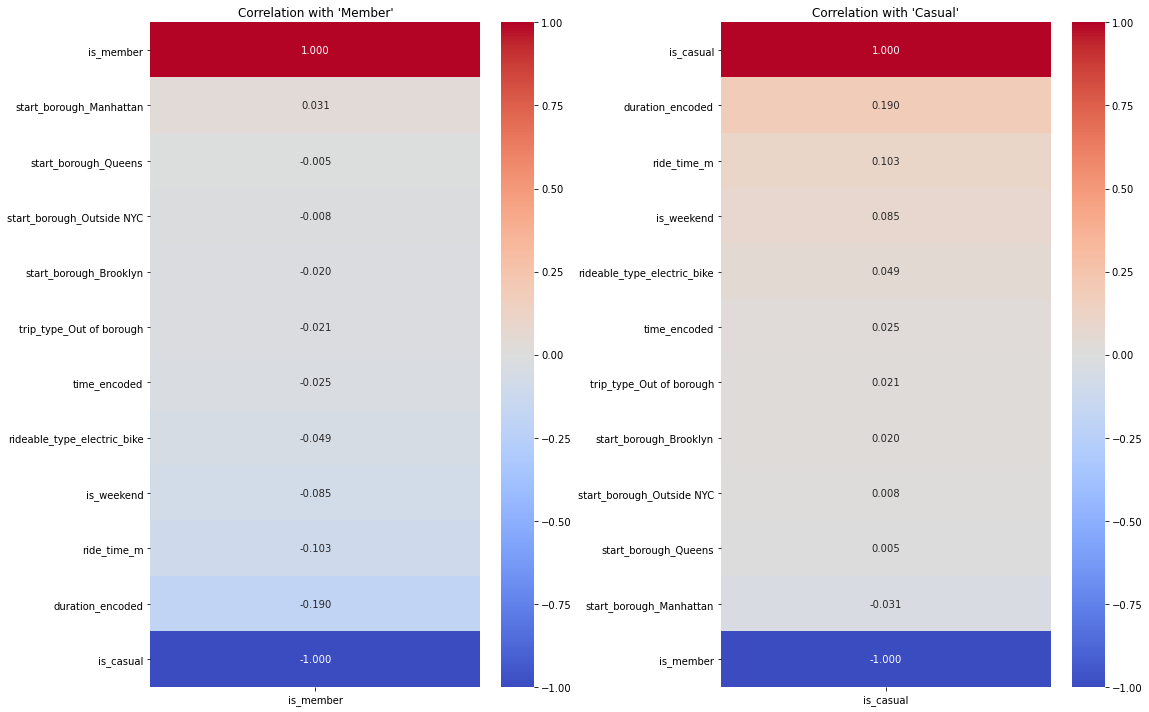

In [21]:
### Preparation: Ensure numeric encoding
df['duration_encoded'] = df['duration_encoded'].astype(int)
df['time_encoded'] = df['time_encoded'].astype(int)

temp_df = df.copy()
temp_df['is_member'] = df['member_casual'].map({'member': 1, 'casual': 0})
temp_df['is_casual'] = df['member_casual'].map({'casual': 1, 'member': 0})

### Select numeric columns for correlation
numeric_cols = temp_df.select_dtypes(include=['number'])

### Calculate both correlation series
corr_member = numeric_cols.corr()[['is_member']].sort_values(by='is_member', ascending=False)
corr_casual = numeric_cols.corr()[['is_casual']].sort_values(by='is_casual', ascending=False)

### Create the side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

### Member Heatmap (Left)
sns.heatmap(corr_member, annot=True, cmap='coolwarm', center=0, fmt=".3f", ax=ax1)
ax1.set_title("Correlation with 'Member'")

### Casual Heatmap (Right)
sns.heatmap(corr_casual, annot=True, cmap='coolwarm', center=0, fmt=".3f", ax=ax2)
ax2.set_title("Correlation with 'Casual'")

plt.tight_layout()
plt.show()

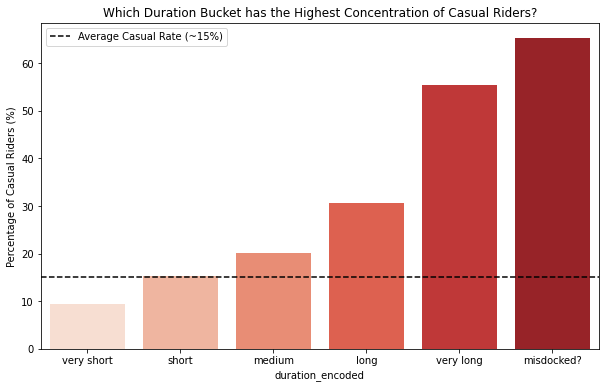

In [22]:
### Create a cross-tabulation of the counts
dist_df = pd.crosstab(df['duration_encoded'], df['member_casual'], normalize='index') * 100

### Map the numbers back to names for the plot
label_map = {0: 'very short', 1: 'short', 2: 'medium', 3: 'long', 4: 'very long', 5: 'misdocked?'}
dist_df.index = dist_df.index.map(label_map)

### Plotting the "Casual" percentage for each bucket
plt.figure(figsize=(10, 6))
sns.barplot(x=dist_df.index, y=dist_df['casual'], palette='Reds')
plt.ylabel('Percentage of Casual Riders (%)')
plt.title('Which Duration Bucket has the Highest Concentration of Casual Riders?')
plt.axhline(15, color='black', linestyle='--', label='Average Casual Rate (~15%)') # Baseline
plt.legend()
plt.show()

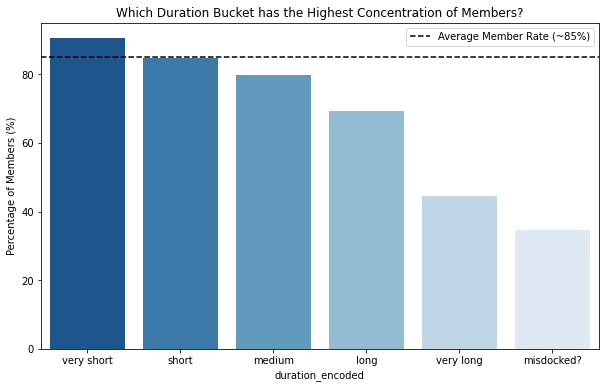

In [23]:
### Create the cross-tabulation (if you haven't already in the current cell)
dist_df = pd.crosstab(df['duration_encoded'], df['member_casual'], normalize='index') * 100

### Map names to the index
label_map = {0: 'very short', 1: 'short', 2: 'medium', 3: 'long', 4: 'very long', 5: 'misdocked?'}
dist_df.index = dist_df.index.map(label_map)

### Plotting the "Member" percentage for each bucket
plt.figure(figsize=(10, 6))
sns.barplot(x=dist_df.index, y=dist_df['member'], palette='Blues_r') # Blues_r makes short trips darker
plt.ylabel('Percentage of Members (%)')
plt.title('Which Duration Bucket has the Highest Concentration of Members?')
plt.axhline(85, color='black', linestyle='--', label='Average Member Rate (~85%)') # Baseline
plt.legend()
plt.show()

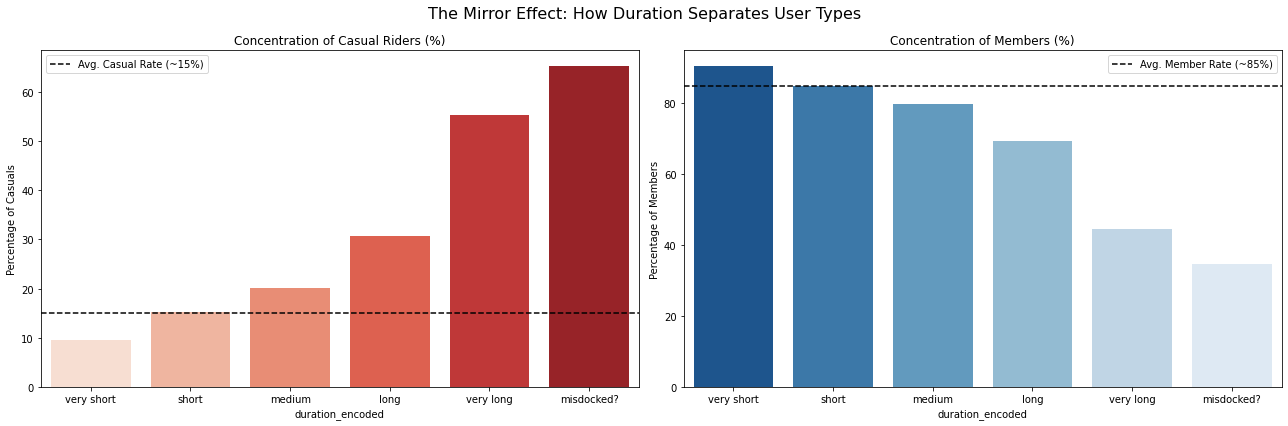

In [24]:
### Prepare the data: Calculate percentages for each duration bucket
dist_df = pd.crosstab(df['duration_encoded'], df['member_casual'], normalize='index') * 100

### Map names to the index for readability
label_map = {0: 'very short', 1: 'short', 2: 'medium', 3: 'long', 4: 'very long', 5: 'misdocked?'}
dist_df.index = dist_df.index.map(label_map)

### Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

### Casual Plot (Left)
sns.barplot(x=dist_df.index, y=dist_df['casual'], palette='Reds', ax=ax1)
ax1.set_title('Concentration of Casual Riders (%)')
ax1.set_ylabel('Percentage of Casuals')
ax1.axhline(15, color='black', linestyle='--', label='Avg. Casual Rate (~15%)')
ax1.legend()

### Member Plot (Right)
sns.barplot(x=dist_df.index, y=dist_df['member'], palette='Blues_r', ax=ax2)
ax2.set_title('Concentration of Members (%)')
ax2.set_ylabel('Percentage of Members')
ax2.axhline(85, color='black', linestyle='--', label='Avg. Member Rate (~85%)')
ax2.legend()

plt.suptitle('The Mirror Effect: How Duration Separates User Types', fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
### Generate the raw percentage table
### This 'normalize=index' means: "Of everyone in this time bucket, what % is casual vs member?"
concentration_table = pd.crosstab(
    df['duration_encoded'], 
    df['member_casual'], 
    normalize='index'
) * 100

### Map the names for clarity
label_map = {
    0: 'very short (<5-10m)', 
    1: 'short', 
    2: 'medium', 
    3: 'long', 
    4: 'very long', 
    5: 'misdocked?'
}
concentration_table.index = concentration_table.index.map(label_map)

### Display the results
print("--- User Concentration by Duration Bucket ---")
print(concentration_table.round(2)) 

--- User Concentration by Duration Bucket ---
member_casual        casual  member
duration_encoded                   
very short (<5-10m)    9.51   90.49
short                 15.22   84.78
medium                20.22   79.78
long                  30.66   69.34
very long             55.35   44.65
misdocked?            65.24   34.76


## Random Forest Model & Logistic Regression Model 

### Train - Test - Split 

In [26]:
y = df['member_casual'].map({'member': 1, 'casual': 0})

cols_to_drop = [
    'member_casual', 'ride_time_m', 'duration_category',
    'start_time_of_day', 'end_time_of_day', 'end_borough'
]
X = df.drop(columns=cols_to_drop)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
### Size of training set versus testing set.
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 2356602
Test set size: 589151


### Random Forest Classifier - Unbalanced 

In [28]:
y = df['member_casual'].map({'member': 1, 'casual': 0})
unbalanced_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
unbalanced_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [29]:
y_pred_unbalanced = unbalanced_model.predict(X_test)
print("--- Unbalanced Model Report ---")
print(classification_report(y_test, y_pred_unbalanced))

--- Unbalanced Model Report ---
              precision    recall  f1-score   support

           0       0.61      0.04      0.08     81171
           1       0.87      1.00      0.93    507980

    accuracy                           0.86    589151
   macro avg       0.74      0.52      0.50    589151
weighted avg       0.83      0.86      0.81    589151



### Random Forest Classifier - Balanced 

In [30]:
model_balance = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    class_weight='balanced'
)
model_balance.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [31]:
y_pred_balance = model_balance.predict(X_test)
print("--- Balanced Model Report ---")
print(classification_report(y_test, y_pred_balance))

--- Balanced Model Report ---
              precision    recall  f1-score   support

           0       0.22      0.59      0.32     81171
           1       0.91      0.67      0.77    507980

    accuracy                           0.66    589151
   macro avg       0.56      0.63      0.54    589151
weighted avg       0.81      0.66      0.71    589151



### Random Forest Classifier - 50/50

In [32]:
### Separate the classes
df_casual = df[df['member_casual'] == 'casual']
df_member = df[df['member_casual'] == 'member']

### Downsample the members
df_member_downsampled = df_member.sample(n=len(df_casual), random_state=42)

### Combine casual and downsampled memebers
df_5050 = pd.concat([df_casual, df_member_downsampled])

### Re-Run X and y split
y_50 = df_5050['member_casual'].map({'member': 1, 'casual': 0})

cols_to_drop_50 = [
    'member_casual', 'ride_time_m', 'duration_category', 
    'start_time_of_day', 'end_time_of_day', 'end_borough'
]

X_50 = df_5050.drop(columns=cols_to_drop_50, errors='ignore')

### Split and Train Data
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(X_50, y_50, test_size=0.2, random_state=42)

In [33]:
model_5050 = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=42
)
model_5050.fit(X_train_50, y_train_50)

RandomForestClassifier(max_depth=10, random_state=42)

In [34]:
y_pred_50 = model_5050.predict(X_test_50)

print("--- 50/50 Downsampled Model Report ---")
print(classification_report(y_test_50, y_pred_50))

--- 50/50 Downsampled Model Report ---
              precision    recall  f1-score   support

           0       0.63      0.61      0.62     81412
           1       0.62      0.65      0.63     81606

    accuracy                           0.63    163018
   macro avg       0.63      0.63      0.63    163018
weighted avg       0.63      0.63      0.63    163018



### Overall Results 

In [35]:
### Prints results to a Dataframe.
results = pd.DataFrame({
    'Method': ['Unbalanced (Baseline)', 'Balanced Weights', '50/50 Undersampling'],
    'Accuracy': [0.86, 0.65, 0.63],
    'Casual Precision': [0.60, 0.22, 0.63],
    'Casual Recall': [0.04, 0.60, 0.61],
    'Casual F1-Score': [0.08, 0.32, 0.62]
})

results

,Method,Accuracy,Casual Precision,Casual Recall,Casual F1-Score
0,Unbalanced (Baseline),0.86,0.60,0.04,0.08
1,Balanced Weights,0.65,0.22,0.60,0.32
2,50/50 Undersampling,0.63,0.63,0.61,0.62


### Confusion Matrix 

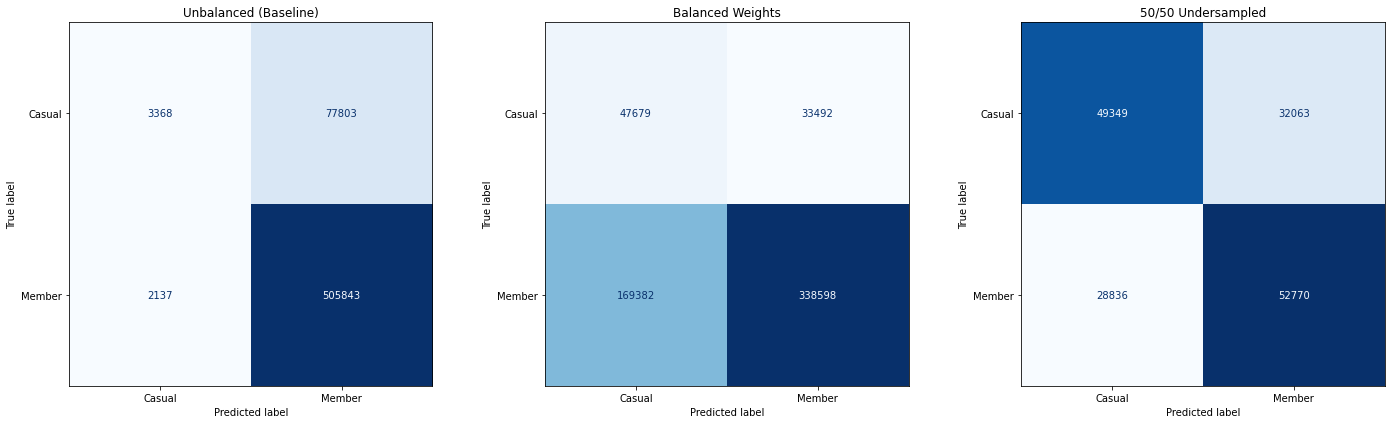

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

### List of models and their respective test data to iterate through
models = [
    (unbalanced_model, X_test, y_test, "Unbalanced (Baseline)"),
    (model_balance, X_test, y_test, "Balanced Weights"),
    (model_5050, X_test_50, y_test_50, "50/50 Undersampled")
]

for i, (m, x_t, y_t, title) in enumerate(models):
    y_pred = m.predict(x_t)
    cm = confusion_matrix(y_t, y_pred)
    
    ### We normalize by 'true' to see percentages.
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Casual', 'Member'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(title)

plt.tight_layout()
plt.show()

### Logistic Regression on 50/50 Model 

In [37]:
### max_iter=1000 to ensure the model has enough time to find the best fit
log_reg_50 = LogisticRegression(max_iter=1000, random_state=42)

### Fit the model
log_reg_50.fit(X_train_50, y_train_50)

### Predict and Report
y_pred_log = log_reg_50.predict(X_test_50)

print("--- Logistic Regression (50/50) Report ---")

### Define names in the order of the mapping (0 = casual, 1 = member)
print(classification_report(y_test_50, y_pred_log, target_names=['Casual', 'Member']))

--- Logistic Regression (50/50) Report ---
              precision    recall  f1-score   support

      Casual       0.62      0.58      0.60     81412
      Member       0.61      0.65      0.63     81606

    accuracy                           0.61    163018
   macro avg       0.62      0.61      0.61    163018
weighted avg       0.62      0.61      0.61    163018



In [38]:
coef_df = pd.DataFrame({
    'Feature': X_50.columns,
    'Coefficient': log_reg_50.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)


                       Feature  Coefficient
7     trip_type_Out of borough     0.521462
4      start_borough_Manhattan     0.501577
3       start_borough_Brooklyn     0.312353
6         start_borough_Queens     0.221000
2                 time_encoded    -0.051960
8  rideable_type_electric_bike    -0.444949
0                   is_weekend    -0.463250
5    start_borough_Outside NYC    -0.519051
1             duration_encoded    -0.523417


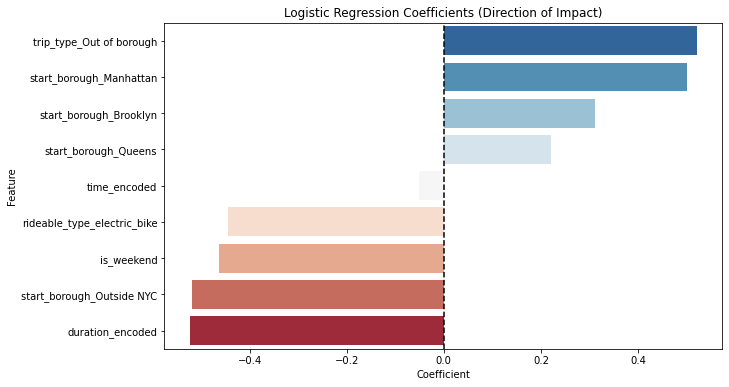

In [39]:
### Initialize and Fit using the same name
log_reg_50 = LogisticRegression(max_iter=1000, random_state=42)
log_reg_50.fit(X_train_50, y_train_50)

### Create the importance dataframe
importance_log = pd.DataFrame({
    'Feature': X_50.columns,
    'Coefficient': log_reg_50.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

### Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance_log, palette='RdBu_r')
plt.axvline(0, color='black', ls='--')
plt.title('Logistic Regression Coefficients (Direction of Impact)')
plt.show()

### Feature Importance 

In [40]:
### Get Random Forest Importance
rf_importance = pd.DataFrame({
    'Feature': X_50.columns,
    'Importance': model_5050.feature_importances_
}).sort_values(by='Importance', ascending=False)

###  Get Logistic Regression Coefficients (using absolute values for magnitude)
lr_importance = pd.DataFrame({
    'Feature': X_50.columns,
    'Abs_Coefficient': np.abs(log_reg_50.coef_[0])
}).sort_values(by='Abs_Coefficient', ascending=False)

### Display them side-by-side
print("RF Top Features:")
print(rf_importance.head(3))
print("\nLogReg Top Features:")
print(lr_importance.head(3))

RF Top Features:
            Feature  Importance
1  duration_encoded    0.601612
0        is_weekend    0.116592
2      time_encoded    0.103231

LogReg Top Features:
                     Feature  Abs_Coefficient
1           duration_encoded         0.523417
7   trip_type_Out of borough         0.521462
5  start_borough_Outside NYC         0.519051
